# Task 2 — Customer Retention & Churn Analysis
Telco Customer Churn dataset (7,043 customers, 21 columns).
Goal: measure churn, find which segments drive it, and quantify revenue at risk.

## 1. Load & Inspect
Load the data and run inspection utilities to check shape, dtypes, duplicates, and nulls.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
from utilities.cleaning import report, check_categories
from utilities.analyze import (
       get_baseline_churn_rate, get_churn_by, get_lost_revenue,
       get_retention_curve, get_dashboard,
)

df = pd.read_csv('../data/Telco-Customer-Churn.csv')

%load_ext autoreload
%autoreload 2

In [2]:
report(df)

Total rows: 7043, Total columns: 21

Duplicate rows: 0

No missing values

The first and last 5 rows of the dataset:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No   

In [3]:
check_categories(df)

Categories in gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Categories in Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Categories in Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Categories in PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Categories in MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Categories in InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Categories in OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Categories in OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

Categories in DeviceProtection
DeviceProtection
No                     30

## 2. Clean
Fix `TotalCharges`: 11 new customers (tenure = 0) have blank charges. Filled with 0 and converted the column to float.

In [4]:
# coerced = pd.to_numeric(df["TotalCharges"], errors="coerce")
#
# print(coerced.isnull().sum())
# print(df[coerced.isnull()])

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

## 3. Analysis

### 3.1 Overall churn rate
Baseline: 26.5% of customers churned. Every segment below is measured against this.

In [6]:
df["Churn_binary"] = (df["Churn"] == "Yes").astype(int)
churn_rate = get_baseline_churn_rate(df)

print(f"Churn rate: {churn_rate:.1%}")

# print(df["Churn"].value_counts(normalize=True))

Churn rate: 26.5%


### 3.2 Churn by contract type
Hypothesis: longer contracts retain customers better.

In [7]:
contract_churn = get_churn_by(df, "Contract")
print(contract_churn)

                customers  churn_rate
Contract                             
Month-to-month       3875    0.427097
One year             1473    0.112695
Two year             1695    0.028319


### 3.3 Churn by tenure bucket
Hypothesis: newer customers churn more than long-tenured ones.

In [8]:
df["Tenure_Tier"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, float('inf')],
    labels=["0-1 yr", "1-2 yrs", "2-4 yrs", ">4 yrs"],
    include_lowest=True,
)

tenure_churn = get_churn_by(df, "Tenure_Tier")
print(tenure_churn)

             customers  churn_rate
Tenure_Tier                       
0-1 yr            2186    0.474382
1-2 yrs           1024    0.287109
2-4 yrs           1594    0.203890
>4 yrs            2239    0.095132


### 3.4 Churn by payment method
Hypothesis: payment friction (manual methods) correlates with churn.

In [9]:
payment_method_churn = get_churn_by(df, "PaymentMethod")
print(payment_method_churn)

                           customers  churn_rate
PaymentMethod                                   
Bank transfer (automatic)       1544    0.167098
Credit card (automatic)         1522    0.152431
Electronic check                2365    0.452854
Mailed check                    1612    0.191067


### 3.5 Churn by services
Reusable `churn_by()` function applied to internet and add-on services.

In [10]:
internet_churn = get_churn_by(df, "InternetService")
print(internet_churn)

security_churn = get_churn_by(df, "OnlineSecurity")
print(security_churn)

support_churn = get_churn_by(df, "TechSupport")
print(support_churn)

tv_churn = get_churn_by(df, "StreamingTV")
print(tv_churn)

movies_churn = get_churn_by(df, "StreamingMovies")
print(movies_churn)

                 customers  churn_rate
InternetService                       
DSL                   2421    0.189591
Fiber optic           3096    0.418928
No                    1526    0.074050
                     customers  churn_rate
OnlineSecurity                            
No                        3498    0.417667
No internet service       1526    0.074050
Yes                       2019    0.146112
                     customers  churn_rate
TechSupport                               
No                        3473    0.416355
No internet service       1526    0.074050
Yes                       2044    0.151663
                     customers  churn_rate
StreamingTV                               
No                        2810    0.335231
No internet service       1526    0.074050
Yes                       2707    0.300702
                     customers  churn_rate
StreamingMovies                           
No                        2785    0.336804
No internet service       1526 

### 3.6 Cross-check: do drivers overlap?
Checking whether contract type and internet service describe the same underlying customers.

In [11]:
pd.crosstab(df["Contract"], df["InternetService"], normalize="index")

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,0.315613,0.549161,0.135226
One year,0.386965,0.365920,0.247115
Two year,0.370501,0.253097,0.376401


### 3.7 Revenue at risk
Churn rate measures volume, but the business cares about lost revenue. Quantify monthly revenue lost to churn by segment.

In [12]:
contract_lost_revenue = get_lost_revenue(df, "Contract")
print(contract_lost_revenue)

tenure_lost_revenue = get_lost_revenue(df, "Tenure_Tier")
print(tenure_lost_revenue)

payment_lost_revenue = get_lost_revenue(df, "PaymentMethod")
print(payment_lost_revenue)

internet_lost_revenue = get_lost_revenue(df, "InternetService")
print(internet_lost_revenue)

security_lost_revenue = get_lost_revenue(df, "OnlineSecurity")
print(security_lost_revenue)

support_lost_revenue = get_lost_revenue(df, "TechSupport")
print(support_lost_revenue)

tv_lost_revenue = get_lost_revenue(df, "StreamingTV")
print(tv_lost_revenue)

movies_lost_revenue = get_lost_revenue(df, "StreamingMovies")
print(movies_lost_revenue)

                customers  churn_rate  total_revenue  lost_revenue
Contract                                                          
Month-to-month       3875    0.427097      257294.15     120847.10
One year             1473    0.112695       95816.60      14118.45
Two year             1695    0.028319      103005.85       4165.30
             customers  churn_rate  total_revenue  lost_revenue
Tenure_Tier                                                    
0-1 yr            2186    0.474382      122629.75      68954.25
1-2 yrs           1024    0.287109       62829.85      23081.65
2-4 yrs           1594    0.203890      105093.30      27462.50
>4 yrs            2239    0.095132      165563.70      19632.45
                           customers  churn_rate  total_revenue  lost_revenue
PaymentMethod                                                                
Bank transfer (automatic)       1544    0.167098      103745.45      20091.90
Credit card (automatic)         1522    0.15243

### 3.8 Tenure retention curve
What % of customers remain at each month of tenure? Visualises where the company loses people over time.

In [13]:
retention_curve = get_retention_curve(df)
print(retention_curve)

        total_customers  churn_rate  retention_rate
tenure                                             
0                    11    0.000000        1.000000
1                   613    0.619902        0.380098
2                   238    0.516807        0.483193
3                   200    0.470000        0.530000
4                   176    0.471591        0.528409
...                 ...         ...             ...
68                  100    0.090000        0.910000
69                   95    0.084211        0.915789
70                  119    0.092437        0.907563
71                  170    0.035294        0.964706
72                  362    0.016575        0.983425

[73 rows x 3 columns]


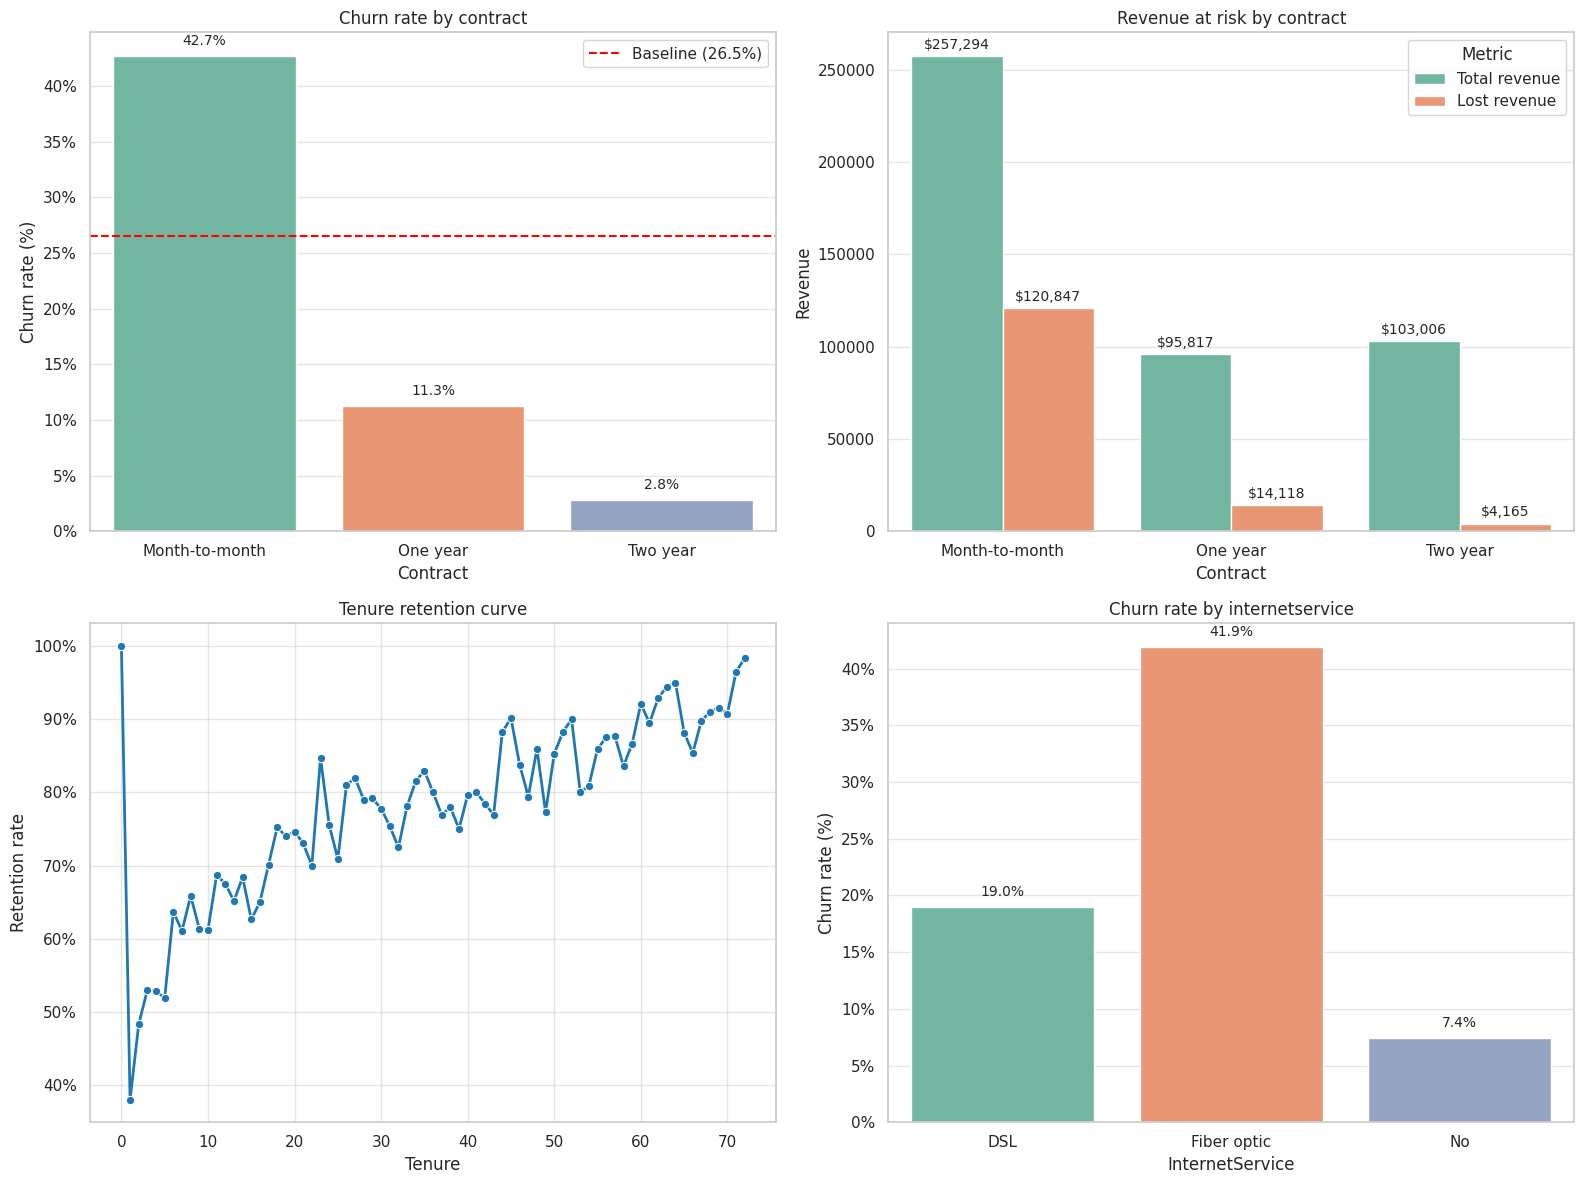

In [14]:
#baseline = get_baseline_churn_rate(df)
get_dashboard(
    contract_churn,
    contract_lost_revenue,
    retention_curve,
    internet_churn,
    baseline=churn_rate,
    save_path="../outputs/dashboard.png",
   )

In [15]:
df.to_csv('../data/Churn_Analysis.csv', index=False)